# MultiExitViT with DeeBERT-style entropy early exit

This notebook keeps the original two intermediate exits `[2, 5]`, but changes inference to normalized-entropy-based early exit. Larger entropy threshold `S` means more aggressive early exit.

Important implementation choices in this version:

- Training/evaluation loaders use `num_workers=0` to avoid Colab/Jupyter multiprocessing DataLoader shutdown warnings.
- Training still uses mini-batches.
- Actual measured latency uses a separate `latency_loader` with `batch_size=1`, matching the DeeBERT-style single-sample early-exit measurement.
- Final-only baseline latency is also measured with `batch_size=1`.
- Expected computation saving and measured latency saving are reported separately.


In [1]:
!nvidia-smi

!pip install -q timm torchinfo

Sat May 23 03:00:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!git clone https://gitlab.au.dk/maleci/multiexitvit.git
!ls -R multiexitvit | head -100

Cloning into 'multiexitvit'...
remote: Enumerating objects: 18, done.
remote: Total 18 (delta 0), reused 0 (delta 0), pack-reused 18 (from 1)
Receiving objects: 100% (18/18), 657.63 KiB | 360.00 KiB/s, done.
Resolving deltas: 100% (10/10), done.
multiexitvit:
calculate_flops.ipynb
calculate_maes.ipynb
cw.ipynb
ee.ipynb
plots.ipynb
precompute_cifar_features.ipynb
precompute_disco_features.ipynb
precompute_fashion_mnist_features.ipynb
README.md
train_cifar100_backbone.ipynb
train_cifar10_backbone.ipynb
train_disco_backbone.ipynb
train_fashion_mnist_backbone.ipynb


In [3]:
import os
import time
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import timm
from torch.utils.data import DataLoader, random_split
from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [4]:
# Dataset
NUM_CLASSES = 10
IMAGE_SIZE = 224

# Model
MODEL_NAME = "vit_tiny_patch16_224"

# Keep the original two-exit setting for stability and presentation clarity.
# ViT-tiny has 12 transformer blocks. We attach exits after block 2 and block 5.
EXIT_BLOCKS = [2, 5]
FINAL_EXIT_NAME = "final"

# Training
BATCH_SIZE = 128

# DeeBERT-style actual latency measurement uses single-sample inference.
# Keep training/test evaluation batched, but use this for latency only.
LATENCY_BATCH_SIZE = 1

EPOCHS_HEAD_ONLY = 5       # backbone freeze, train only exit heads
EPOCHS_FINE_TUNE = 5       # optional: unfreeze last blocks and fine-tune
LR_HEAD = 1e-3
LR_FINE_TUNE = 3e-5
WEIGHT_DECAY = 1e-4

# Fast debugging only. Use None for the full dataset.
TRAIN_LIMIT = None
TEST_LIMIT = None

# Entropy thresholds for DeeBERT-style early exit.
# normalized entropy is in [0, 1].
# Larger S means more aggressive early exit.
ENTROPY_THRESHOLDS = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

# Set a small number such as 1000 for faster debugging.
# Use None for the full CIFAR-10 test set.
MAX_LATENCY_SAMPLES = None


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])

full_train = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

if TRAIN_LIMIT is not None:
    full_train, _ = random_split(
        full_train,
        [TRAIN_LIMIT, len(full_train) - TRAIN_LIMIT],
        generator=torch.Generator().manual_seed(SEED)
    )

if TEST_LIMIT is not None:
    test_dataset, _ = random_split(
        test_dataset,
        [TEST_LIMIT, len(test_dataset) - TEST_LIMIT],
        generator=torch.Generator().manual_seed(SEED)
    )

val_size = int(0.1 * len(full_train))
train_size = len(full_train) - val_size

train_dataset, val_dataset = random_split(
    full_train,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)



# Separate DeeBERT-style latency loader.
# Actual measured latency uses batch_size=1 so that each sample can stop immediately at its exit.
latency_loader = DataLoader(
    test_dataset,
    batch_size=LATENCY_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("train:", len(train_dataset))
print("val:", len(val_dataset))
print("test:", len(test_dataset))
print("latency samples:", len(test_dataset), "batch_size:", LATENCY_BATCH_SIZE)

100%|██████████| 170M/170M [00:04<00:00, 40.4MB/s]


train: 45000
val: 5000
test: 10000
latency samples: 10000 batch_size: 1


In [6]:
class ExitHead(nn.Module):
    def __init__(self, embed_dim, num_classes, hidden_dim=256, dropout=0.1):
        super().__init__()
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        # x: [B, N, C]
        cls_token = x[:, 0]  # CLS token
        return self.head(cls_token)


class MultiExitViT(nn.Module):
    def __init__(
        self,
        model_name="vit_tiny_patch16_224",
        num_classes=10,
        exit_blocks=[2, 5],
        pretrained=True
    ):
        super().__init__()

        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0
        )

        self.exit_blocks = set(exit_blocks)

        embed_dim = self.backbone.num_features
        depth = len(self.backbone.blocks)

        print(f"Loaded backbone: {model_name}")
        print(f"embed_dim: {embed_dim}")
        print(f"num transformer blocks: {depth}")
        print(f"early exits after blocks: {exit_blocks}")

        self.exit_heads = nn.ModuleDict()
        for b in exit_blocks:
            self.exit_heads[str(b)] = ExitHead(embed_dim, num_classes)

        self.final_head = ExitHead(embed_dim, num_classes)

    def forward_features_with_exits(self, x):
        outputs = {}

        # timm ViT 내부 forward_features 흐름을 수동으로 분해
        x = self.backbone.patch_embed(x)
        x = self.backbone._pos_embed(x)

        if hasattr(self.backbone, "patch_drop"):
            x = self.backbone.patch_drop(x)

        if hasattr(self.backbone, "norm_pre"):
            x = self.backbone.norm_pre(x)

        for i, block in enumerate(self.backbone.blocks, start=1):
            x = block(x)

            if i in self.exit_blocks:
                outputs[str(i)] = self.exit_heads[str(i)](x)

        x = self.backbone.norm(x)
        outputs["final"] = self.final_head(x)

        return outputs

    def forward(self, x):
        return self.forward_features_with_exits(x)


model = MultiExitViT(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES,
    exit_blocks=EXIT_BLOCKS,
    pretrained=True
).to(device)

print(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Loaded backbone: vit_tiny_patch16_224
embed_dim: 192
num transformer blocks: 12
early exits after blocks: [2, 5]
MultiExitViT(
  (backbone): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=192, out_features=576, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=192, out_features=192, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((192,), eps=1e-06, elementwise_a

In [7]:
def multi_exit_loss(outputs, targets, exit_weights=None):
    """
    outputs:
      {
        "2": logits,
        "5": logits,
        "final": logits
      }
    """
    if exit_weights is None:
        exit_weights = {k: 1.0 for k in outputs.keys()}

    loss = 0.0
    for k, logits in outputs.items():
        loss = loss + exit_weights.get(k, 1.0) * F.cross_entropy(logits, targets)

    return loss


@torch.no_grad()
def evaluate_all_exits(model, loader):
    model.eval()

    correct = {}
    total = 0

    for images, labels in tqdm(loader, desc="eval all exits", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        for k, logits in outputs.items():
            preds = logits.argmax(dim=1)
            correct[k] = correct.get(k, 0) + (preds == labels).sum().item()

        total += labels.size(0)

    acc = {k: v / total for k, v in correct.items()}
    return acc


def train_one_epoch(model, loader, optimizer, epoch, exit_weights=None):
    model.train()

    total_loss = 0.0
    total_samples = 0

    pbar = tqdm(loader, desc=f"train epoch {epoch}", leave=False)

    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = multi_exit_loss(outputs, labels, exit_weights)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        pbar.set_postfix(loss=total_loss / total_samples)

    return total_loss / total_samples

In [8]:
# backbone 전체 freeze
for p in model.backbone.parameters():
    p.requires_grad = False

# exit heads만 train
for p in model.exit_heads.parameters():
    p.requires_grad = True

for p in model.final_head.parameters():
    p.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"trainable params: {trainable_params:,}")
print(f"total params: {total_params:,}")

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY
)

# final을 조금 더 중요하게 줄 수도 있음
exit_weights = {
    "2": 0.5,
    "5": 0.7,
    "final": 1.0
}

for epoch in range(1, EPOCHS_HEAD_ONLY + 1):
    loss = train_one_epoch(model, train_loader, optimizer, epoch, exit_weights)
    val_acc = evaluate_all_exits(model, val_loader)

    print(f"[Head-only Epoch {epoch}] loss={loss:.4f}")
    print("val acc:", {k: round(v, 4) for k, v in val_acc.items()})

trainable params: 157,086
total params: 5,681,502


train epoch 1:   0%|          | 0/352 [00:00<?, ?it/s]

eval all exits:   0%|          | 0/40 [00:00<?, ?it/s]

[Head-only Epoch 1] loss=2.5629
val acc: {'2': 0.4334, '5': 0.5782, 'final': 0.793}


train epoch 2:   0%|          | 0/352 [00:00<?, ?it/s]

...

eval all exits:   0%|          | 0/40 [00:00<?, ?it/s]

[Head-only Epoch 4] loss=1.8753
val acc: {'2': 0.5128, '5': 0.657, 'final': 0.8268}


train epoch 5:   0%|          | 0/352 [00:00<?, ?it/s]

eval all exits:   0%|          | 0/40 [00:00<?, ?it/s]

[Head-only Epoch 5] loss=1.8136
val acc: {'2': 0.5196, '5': 0.6614, 'final': 0.831}


In [9]:
# # 일단 전체 freeze
# for p in model.backbone.parameters():
#     p.requires_grad = False

# # 마지막 2개 transformer block만 unfreeze
# NUM_UNFREEZE_BLOCKS = 2

# for block in model.backbone.blocks[-NUM_UNFREEZE_BLOCKS:]:
#     for p in block.parameters():
#         p.requires_grad = True

# # final norm도 unfreeze
# for p in model.backbone.norm.parameters():
#     p.requires_grad = True

# # heads는 계속 train
# for p in model.exit_heads.parameters():
#     p.requires_grad = True

# for p in model.final_head.parameters():
#     p.requires_grad = True

# trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f"trainable params after partial unfreeze: {trainable_params:,}")

# optimizer = optim.AdamW(
#     filter(lambda p: p.requires_grad, model.parameters()),
#     lr=LR_FINE_TUNE,
#     weight_decay=WEIGHT_DECAY
# )

# for epoch in range(1, EPOCHS_FINE_TUNE + 1):
#     loss = train_one_epoch(model, train_loader, optimizer, epoch, exit_weights)
#     val_acc = evaluate_all_exits(model, val_loader)

#     print(f"[Fine-tune Epoch {epoch}] loss={loss:.4f}")
#     print("val acc:", {k: round(v, 4) for k, v in val_acc.items()})

In [10]:
ckpt_path = "multi_exit_vit_cifar10_entropy_ready.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "model_name": MODEL_NAME,
    "exit_blocks": EXIT_BLOCKS,
    "num_classes": NUM_CLASSES,
}, ckpt_path)

print("saved:", ckpt_path)


saved: multi_exit_vit_cifar10_entropy_ready.pth


In [11]:
ckpt_path = "multi_exit_vit_cifar10_entropy_ready.pth"

checkpoint = torch.load(ckpt_path, map_location=device)

model = MultiExitViT(
    model_name=checkpoint["model_name"],
    num_classes=checkpoint["num_classes"],
    exit_blocks=checkpoint["exit_blocks"],
    pretrained=False
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("checkpoint loaded")


Loaded backbone: vit_tiny_patch16_224
embed_dim: 192
num transformer blocks: 12
early exits after blocks: [2, 5]
checkpoint loaded


In [12]:
test_acc = evaluate_all_exits(model, test_loader)

print("Standalone test accuracy per exit")
for k, v in test_acc.items():
    print(f"exit {k}: {v:.4f}")

eval all exits:   0%|          | 0/79 [00:00<?, ?it/s]

Standalone test accuracy per exit
exit 2: 0.5195
exit 5: 0.6601
exit final: 0.8330


In [13]:
import math


def normalized_entropy_from_logits(logits, eps=1e-12):
    """
    logits: [B, num_classes]
    return: normalized entropy in [0, 1]

    Lower entropy = more confident.
    Higher entropy = more uncertain.
    """
    probs = F.softmax(logits, dim=1)
    log_probs = torch.log(probs + eps)
    entropy = -(probs * log_probs).sum(dim=1)
    normalized_entropy = entropy / math.log(logits.size(1))
    return normalized_entropy


@torch.no_grad()
def dynamic_inference_single_real_entropy(model, images, entropy_threshold):
    """
    DeeBERT-style actual early-exit inference for one image.

    Rule:
      normalized_entropy <= entropy_threshold -> exit at that branch
      normalized_entropy >  entropy_threshold -> continue to deeper blocks

    This function is intentionally batch_size=1 only.
    It measures single-sample latency, matching the DeeBERT notebook style.
    """
    model.eval()

    batch_size = images.size(0)
    assert batch_size == 1, "Actual early-exit latency measurement uses batch_size=1."

    x = model.backbone.patch_embed(images)
    x = model.backbone._pos_embed(x)

    if hasattr(model.backbone, "patch_drop"):
        x = model.backbone.patch_drop(x)

    if hasattr(model.backbone, "norm_pre"):
        x = model.backbone.norm_pre(x)

    exit_order = [str(b) for b in EXIT_BLOCKS] + ["final"]

    for block_idx, block in enumerate(model.backbone.blocks, start=1):
        x = block(x)

        if block_idx in EXIT_BLOCKS:
            exit_name = str(block_idx)
            exit_idx = exit_order.index(exit_name)

            logits = model.exit_heads[exit_name](x)
            entropy = normalized_entropy_from_logits(logits)
            pred = logits.argmax(dim=1)

            if entropy.item() <= entropy_threshold:
                return logits, pred, entropy.item(), block_idx, exit_idx

    # Final exit.
    x = model.backbone.norm(x)
    logits = model.final_head(x)
    entropy = normalized_entropy_from_logits(logits)
    pred = logits.argmax(dim=1)

    final_block = len(model.backbone.blocks)
    final_idx = exit_order.index("final")

    return logits, pred, entropy.item(), final_block, final_idx


@torch.no_grad()
def final_only_forward_single(model, images):
    """
    Final-only baseline forward for one image.
    This avoids computing intermediate exit heads and is used as the latency baseline.
    """
    batch_size = images.size(0)
    assert batch_size == 1, "Final-only latency measurement uses batch_size=1."

    x = model.backbone.patch_embed(images)
    x = model.backbone._pos_embed(x)

    if hasattr(model.backbone, "patch_drop"):
        x = model.backbone.patch_drop(x)

    if hasattr(model.backbone, "norm_pre"):
        x = model.backbone.norm_pre(x)

    for block in model.backbone.blocks:
        x = block(x)

    x = model.backbone.norm(x)
    logits = model.final_head(x)
    return logits


@torch.no_grad()
def evaluate_final_only_baseline_latency_single(
    model,
    loader,
    warmup_samples=20,
    max_samples=None,
):
    """
    DeeBERT-style final-only latency baseline.
    The loader must use batch_size=1.
    """
    model.eval()

    # GPU warmup.
    for i, (images, labels) in enumerate(loader):
        if i >= warmup_samples:
            break
        images = images.to(device, non_blocking=True)
        _ = final_only_forward_single(model, images)

    if device.type == "cuda":
        torch.cuda.synchronize()

    correct = 0
    total = 0

    start_time = time.perf_counter()

    for step, (images, labels) in enumerate(tqdm(loader, desc="final-only baseline latency", leave=False)):
        if max_samples is not None and step >= max_samples:
            break

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = final_only_forward_single(model, images)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start_time

    return {
        "accuracy": correct / total,
        "elapsed_sec": elapsed,
        "ms_per_sample": 1000.0 * elapsed / total,
        "num_samples": total,
    }


@torch.no_grad()
def evaluate_dynamic_entropy_latency_single(
    model,
    loader,
    entropy_threshold,
    warmup_samples=20,
    max_samples=None,
):
    """
    DeeBERT-style actual early-exit latency measurement.
    The loader must use batch_size=1.
    """
    model.eval()

    exit_order = [str(b) for b in EXIT_BLOCKS] + ["final"]
    num_exits = len(exit_order)
    total_blocks = len(model.backbone.blocks)

    exit_counts = np.zeros(num_exits, dtype=np.int64)

    # GPU warmup.
    for i, (images, labels) in enumerate(loader):
        if i >= warmup_samples:
            break
        images = images.to(device, non_blocking=True)
        _ = dynamic_inference_single_real_entropy(
            model,
            images,
            entropy_threshold=entropy_threshold,
        )

    if device.type == "cuda":
        torch.cuda.synchronize()

    correct = 0
    total = 0

    start_time = time.perf_counter()

    for step, (images, labels) in enumerate(tqdm(loader, desc=f"entropy S={entropy_threshold:.2f} latency", leave=False)):
        if max_samples is not None and step >= max_samples:
            break

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits, preds, entropy, exit_block, exit_idx = dynamic_inference_single_real_entropy(
            model,
            images,
            entropy_threshold=entropy_threshold,
        )

        correct += (preds == labels).sum().item()
        total += labels.size(0)
        exit_counts[exit_idx] += 1

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start_time

    exit_ratios = exit_counts / total
    block_depths = EXIT_BLOCKS + [total_blocks]

    avg_exit_block = sum(
        exit_ratios[i] * block_depths[i]
        for i in range(num_exits)
    )

    compute_ratio = avg_exit_block / total_blocks
    expected_saving = 1.0 - compute_ratio
    speedup_proxy = total_blocks / avg_exit_block

    result = {
        "S_entropy_threshold": entropy_threshold,
        "accuracy": correct / total,
        "elapsed_sec": elapsed,
        "ms_per_sample": 1000.0 * elapsed / total,
        "avg_exit_block": avg_exit_block,
        "compute_ratio": compute_ratio,
        "expected_saving": expected_saving,
        "speedup_proxy": speedup_proxy,
        "num_samples": total,
    }

    for i, exit_name in enumerate(exit_order):
        result[f"exit_{exit_name}_ratio"] = exit_ratios[i]

    return result


# 1) Measure final-only baseline latency with batch_size=1.
final_baseline = evaluate_final_only_baseline_latency_single(
    model,
    latency_loader,
    max_samples=MAX_LATENCY_SAMPLES,
)

print("Final-only baseline latency")
print(final_baseline)

# 2) Measure real entropy-based early-exit latency with batch_size=1.
actual_latency_results = []

for S in ENTROPY_THRESHOLDS:
    result = evaluate_dynamic_entropy_latency_single(
        model,
        latency_loader,
        entropy_threshold=S,
        max_samples=MAX_LATENCY_SAMPLES,
    )
    actual_latency_results.append(result)
    print(result)

entropy_results = pd.DataFrame(actual_latency_results)

# 3) Add measured latency saving compared with final-only baseline.
baseline_time = final_baseline["elapsed_sec"]
baseline_ms = final_baseline["ms_per_sample"]

entropy_results["measured_saving"] = 1.0 - (entropy_results["elapsed_sec"] / baseline_time)
entropy_results["measured_speedup"] = baseline_time / entropy_results["elapsed_sec"]
entropy_results["measured_saving_percent"] = entropy_results["measured_saving"] * 100.0
entropy_results["expected_saving_percent"] = entropy_results["expected_saving"] * 100.0

# 4) Add a baseline row for table-style comparison.
baseline_row = {
    "S_entropy_threshold": 0.0,
    "accuracy": final_baseline["accuracy"],
    "elapsed_sec": final_baseline["elapsed_sec"],
    "ms_per_sample": final_baseline["ms_per_sample"],
    "avg_exit_block": len(model.backbone.blocks),
    "compute_ratio": 1.0,
    "expected_saving": 0.0,
    "speedup_proxy": 1.0,
    "num_samples": final_baseline["num_samples"],
    "exit_2_ratio": 0.0,
    "exit_5_ratio": 0.0,
    "exit_final_ratio": 1.0,
    "measured_saving": 0.0,
    "measured_speedup": 1.0,
    "measured_saving_percent": 0.0,
    "expected_saving_percent": 0.0,
}

entropy_results_with_baseline = pd.concat(
    [pd.DataFrame([baseline_row]), entropy_results],
    ignore_index=True,
)

# Display DeeBERT-style result table.
display(entropy_results_with_baseline)
print(entropy_results_with_baseline.to_string(index=False))


final-only baseline latency:   0%|          | 0/10000 [00:00<?, ?it/s]

Final-only baseline latency
{'accuracy': 0.833, 'elapsed_sec': 75.82419035399994, 'ms_per_sample': 7.582419035399993, 'num_samples': 10000}


entropy S=0.10 latency:   0%|          | 0/10000 [00:00<?, ?it/s]

{'S_entropy_threshold': 0.1, 'accuracy': 0.8329, 'elapsed_sec': 92.74820769899998, 'ms_per_sample': 9.274820769899998, 'avg_exit_block': np.float64(11.579799999999999), 'compute_ratio': np.float64(0.9649833333333332), 'expected_saving': np.float64(0.03501666666666681), 'speedup_proxy': np.float64(1.036287327933125), 'num_samples': 10000, 'exit_2_ratio': np.float64(0.0017), 'exit_5_ratio': np.float64(0.0576), 'exit_final_ratio': np.float64(0.9407)}


entropy S=0.20 latency:   0%|          | 0/10000 [00:00<?, ?it/s]

...

{'S_entropy_threshold': 0.6, 'accuracy': 0.6868, 'elapsed_sec': 60.619905238, 'ms_per_sample': 6.0619905238, 'avg_exit_block': np.float64(5.1515), 'compute_ratio': np.float64(0.4292916666666667), 'expected_saving': np.float64(0.5707083333333334), 'speedup_proxy': np.float64(2.3294186159371053), 'num_samples': 10000, 'exit_2_ratio': np.float64(0.4549), 'exit_5_ratio': np.float64(0.3285), 'exit_final_ratio': np.float64(0.2166)}


entropy S=0.70 latency:   0%|          | 0/10000 [00:00<?, ?it/s]

{'S_entropy_threshold': 0.7, 'accuracy': 0.6118, 'elapsed_sec': 51.4398967300001, 'ms_per_sample': 5.14398967300001, 'avg_exit_block': np.float64(3.5382), 'compute_ratio': np.float64(0.29485), 'expected_saving': np.float64(0.7051499999999999), 'speedup_proxy': np.float64(3.391555027980329), 'num_samples': 10000, 'exit_2_ratio': np.float64(0.6744), 'exit_5_ratio': np.float64(0.2454), 'exit_final_ratio': np.float64(0.0802)}


,S_entropy_threshold,accuracy,elapsed_sec,ms_per_sample,avg_exit_block,compute_ratio,expected_saving,speedup_proxy,num_samples,exit_2_ratio,exit_5_ratio,exit_final_ratio,measured_saving,measured_speedup,measured_saving_percent,expected_saving_percent
0,0.0,0.8330,75.824190,7.582419,12.0000,1.000000,0.000000,1.000000,10000,0.0000,0.0000,1.0000,0.000000,1.000000,0.000000,0.000000
1,0.1,0.8329,92.748208,9.274821,11.5798,0.964983,0.035017,1.036287,10000,0.0017,0.0576,0.9407,-0.223201,0.817527,-22.320077,3.501667
2,0.2,0.8300,90.140368,9.014037,10.8052,0.900433,0.099567,1.110576,10000,0.0142,0.1504,0.8354,-0.188808,0.841179,-18.880752,9.956667
3,0.3,0.8222,87.246616,8.724662,9.8592,0.821600,0.178400,1.217137,10000,0.0535,0.2294,0.7171,-0.150644,0.869079,-15.064356,17.840000
4,0.4,0.7963,78.984058,7.898406,8.4901,0.707508,0.292492,1.413411,10000,0.1328,0.3117,0.5555,-0.041674,0.959994,-4.167361,29.249167
5,0.5,0.7521,70.064972,7.006497,6.8772,0.573100,0.426900,1.744896,10000,0.2642,0.3544,0.3814,0.075955,1.082198,7.595490,42.690000
6,0.6,0.6868,60.619905,6.061991,5.1515,0.429292,0.570708,2.329419,10000,0.4549,0.3285,0.2166,0.200520,1.250813,20.052024,57.070833
7,0.7,0.6118,51.439897,5.143990,3.5382,0.294850,0.705150,3.391555,10000,0.6744,0.2454,0.0802,0.321590,1.474035,32.158990,70.515000


 S_entropy_threshold  accuracy  elapsed_sec  ms_per_sample  avg_exit_block  compute_ratio  expected_saving  speedup_proxy  num_samples  exit_2_ratio  exit_5_ratio  exit_final_ratio  measured_saving  measured_speedup  measured_saving_percent  expected_saving_percent
                 0.0    0.8330    75.824190       7.582419         12.0000       1.000000         0.000000       1.000000        10000        0.0000        0.0000            1.0000         0.000000          1.000000                 0.000000                 0.000000
                 0.1    0.8329    92.748208       9.274821         11.5798       0.964983         0.035017       1.036287        10000        0.0017        0.0576            0.9407        -0.223201          0.817527               -22.320077                 3.501667
                 0.2    0.8300    90.140368       9.014037         10.8052       0.900433         0.099567       1.110576        10000        0.0142        0.1504            0.8354        -0.188808     

In [14]:
# Compact DeeBERT-style result table for presentation.
summary_cols = [
    "S_entropy_threshold",
    "accuracy",
    "avg_exit_block",
    "expected_saving_percent",
    "speedup_proxy",
    "ms_per_sample",
    "measured_saving_percent",
    "measured_speedup",
    "exit_2_ratio",
    "exit_5_ratio",
    "exit_final_ratio",
]

summary_table = entropy_results_with_baseline[summary_cols].copy()

# Round only for display. Keep entropy_results_with_baseline unchanged.
summary_display = summary_table.copy()
for col in summary_display.columns:
    if col != "S_entropy_threshold":
        summary_display[col] = summary_display[col].astype(float).round(4)

display(summary_display)
print(summary_display.to_string(index=False))


,S_entropy_threshold,accuracy,avg_exit_block,expected_saving_percent,speedup_proxy,ms_per_sample,measured_saving_percent,measured_speedup,exit_2_ratio,exit_5_ratio,exit_final_ratio
0,0.0,0.8330,12.0000,0.0000,1.0000,7.5824,0.0000,1.0000,0.0000,0.0000,1.0000
1,0.1,0.8329,11.5798,3.5017,1.0363,9.2748,-22.3201,0.8175,0.0017,0.0576,0.9407
2,0.2,0.8300,10.8052,9.9567,1.1106,9.0140,-18.8808,0.8412,0.0142,0.1504,0.8354
3,0.3,0.8222,9.8592,17.8400,1.2171,8.7247,-15.0644,0.8691,0.0535,0.2294,0.7171
4,0.4,0.7963,8.4901,29.2492,1.4134,7.8984,-4.1674,0.9600,0.1328,0.3117,0.5555
5,0.5,0.7521,6.8772,42.6900,1.7449,7.0065,7.5955,1.0822,0.2642,0.3544,0.3814
6,0.6,0.6868,5.1515,57.0708,2.3294,6.0620,20.0520,1.2508,0.4549,0.3285,0.2166
7,0.7,0.6118,3.5382,70.5150,3.3916,5.1440,32.1590,1.4740,0.6744,0.2454,0.0802


 S_entropy_threshold  accuracy  avg_exit_block  expected_saving_percent  speedup_proxy  ms_per_sample  measured_saving_percent  measured_speedup  exit_2_ratio  exit_5_ratio  exit_final_ratio
                 0.0    0.8330         12.0000                   0.0000         1.0000         7.5824                   0.0000            1.0000        0.0000        0.0000            1.0000
                 0.1    0.8329         11.5798                   3.5017         1.0363         9.2748                 -22.3201            0.8175        0.0017        0.0576            0.9407
                 0.2    0.8300         10.8052                   9.9567         1.1106         9.0140                 -18.8808            0.8412        0.0142        0.1504            0.8354
                 0.3    0.8222          9.8592                  17.8400         1.2171         8.7247                 -15.0644            0.8691        0.0535        0.2294            0.7171
                 0.4    0.7963          8.490

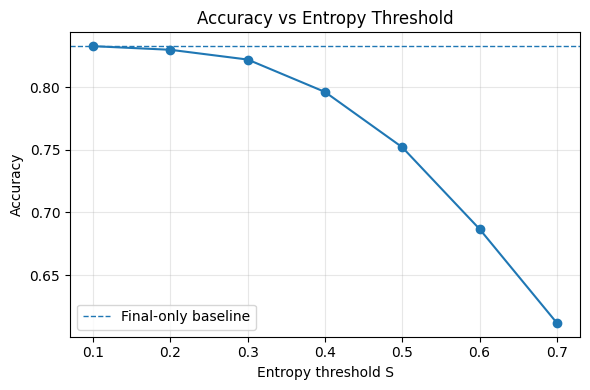

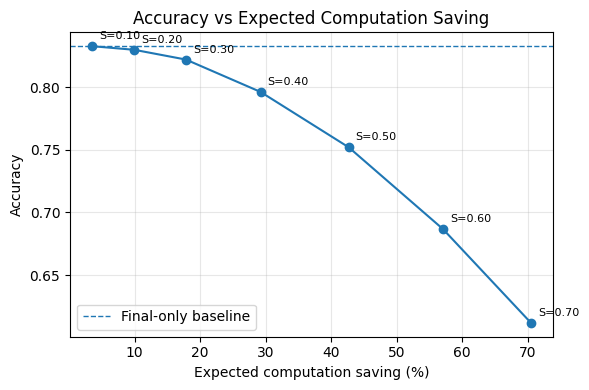

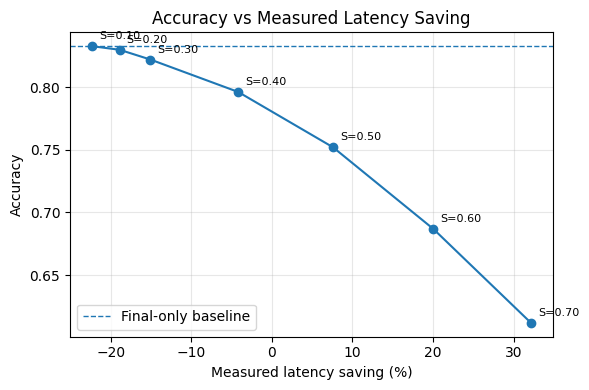

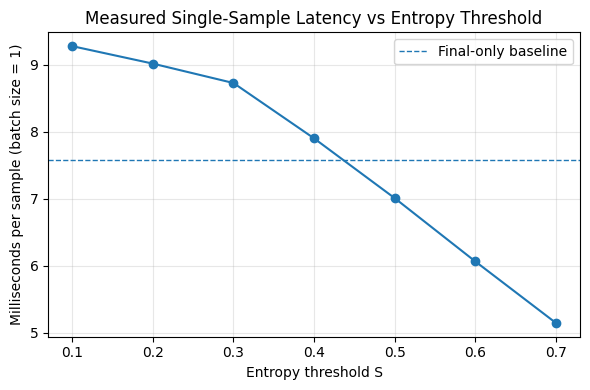

In [15]:
import matplotlib.pyplot as plt

# Exclude final-only baseline row from threshold curves when useful.
plot_results = entropy_results.copy()

plt.figure(figsize=(6, 4))
plt.plot(
    plot_results["S_entropy_threshold"],
    plot_results["accuracy"],
    marker="o"
)
plt.axhline(final_baseline["accuracy"], linestyle="--", linewidth=1, label="Final-only baseline")
plt.xlabel("Entropy threshold S")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Entropy Threshold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(
    plot_results["expected_saving"] * 100.0,
    plot_results["accuracy"],
    marker="o"
)
plt.axhline(final_baseline["accuracy"], linestyle="--", linewidth=1, label="Final-only baseline")
for _, row in plot_results.iterrows():
    plt.annotate(
        f"S={row['S_entropy_threshold']:.2f}",
        (row["expected_saving"] * 100.0, row["accuracy"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8
    )
plt.xlabel("Expected computation saving (%)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Expected Computation Saving")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(
    plot_results["measured_saving"] * 100.0,
    plot_results["accuracy"],
    marker="o"
)
plt.axhline(final_baseline["accuracy"], linestyle="--", linewidth=1, label="Final-only baseline")
for _, row in plot_results.iterrows():
    plt.annotate(
        f"S={row['S_entropy_threshold']:.2f}",
        (row["measured_saving"] * 100.0, row["accuracy"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8
    )
plt.xlabel("Measured latency saving (%)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Measured Latency Saving")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(
    plot_results["S_entropy_threshold"],
    plot_results["ms_per_sample"],
    marker="o"
)
plt.axhline(final_baseline["ms_per_sample"], linestyle="--", linewidth=1, label="Final-only baseline")
plt.xlabel("Entropy threshold S")
plt.ylabel("Milliseconds per sample (batch size = 1)")
plt.title("Measured Single-Sample Latency vs Entropy Threshold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


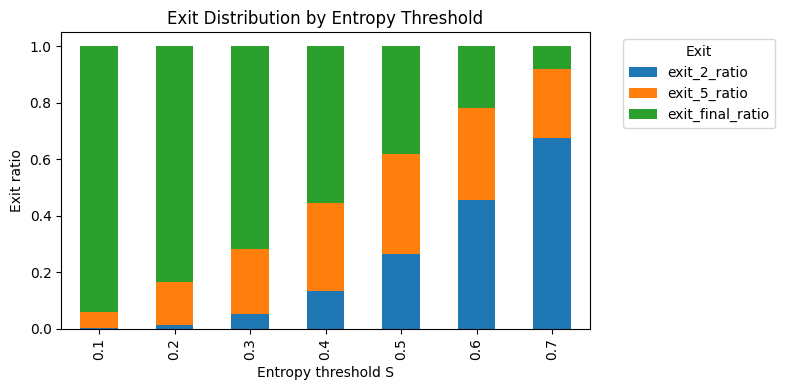

In [16]:
exit_ratio_cols = [
    c for c in entropy_results.columns
    if c.startswith("exit_") and c.endswith("_ratio")
]

plot_df = entropy_results[["S_entropy_threshold"] + exit_ratio_cols].copy()
plot_df = plot_df.set_index("S_entropy_threshold")

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4)
)

ax.set_xlabel("Entropy threshold S")
ax.set_ylabel("Exit ratio")
ax.set_title("Exit Distribution by Entropy Threshold")
ax.legend(title="Exit", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
